## Model 4: Logistic Regression for Clinical Data

### **Purpose:** Second clinical baseline using interpretable logistic regression

### **Data:** Synthetic neonatal dataset (3 burden scenarios)

### **Output:** P(y|X_clinical) - probability of respiratory distress


## 1. Imports

In [34]:
import numpy as np
import pandas as pd
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
import json
import warnings
warnings.filterwarnings('ignore')

## 2. Load Synthetic Neonatal Data

In [35]:
data_dir = Path("../../clinical_data")

# Load all three burden scenarios
df_low = pd.read_csv(data_dir / "neonatal_low_burden.csv")
df_moderate = pd.read_csv(data_dir / "neonatal_moderate_burden.csv")
df_high = pd.read_csv(data_dir / "neonatal_high_burden.csv")

print("="*60)
print("SYNTHETIC NEONATAL DATA LOADED")
print("="*60)
print(f"Low burden: {len(df_low):,} samples")
print(f"Moderate burden: {len(df_moderate):,} samples")
print(f"High burden: {len(df_high):,} samples")
print(f"\nTOTAL: {len(df_low) + len(df_moderate) + len(df_high):,} samples")

# Combine all scenarios (we'll use moderate for training, others for testing)
df = pd.concat([df_low, df_moderate, df_high], ignore_index=True)
print(f"\nCombined shape: {df.shape}")

# Display first few rows
df.head()

SYNTHETIC NEONATAL DATA LOADED
Low burden: 10,000 samples
Moderate burden: 10,000 samples
High burden: 10,000 samples

TOTAL: 30,000 samples

Combined shape: (30000, 17)


,id,sex,gestational_age_weeks,birth_weight_g,head_circumference_cm,maternal_age_years,parity,delivery_mode,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent,bw_category,preterm_category,primary_outcome
0,1,F,36.3,2860,39.8,24,2,vaginal,7,6,36.8,134,45,97,Normal_BW,Late_preterm,healthy
1,2,M,37.8,2640,34.0,15,0,vaginal,9,9,36.5,144,53,95,Normal_BW,Term,healthy
2,3,F,39.6,3010,41.4,27,1,vaginal,9,10,37.2,149,55,98,Normal_BW,Term,healthy
3,4,F,39.0,3230,34.6,31,4,vaginal,9,9,36.7,160,51,98,Normal_BW,Term,healthy
4,5,M,39.0,3630,35.2,27,0,caesarean,9,9,36.9,147,43,98,Normal_BW,Term,healthy


## 3. Process Each Dataset

In [36]:
dataframes = {
    'moderate': df_moderate,
    'low': df_low,
    'high': df_high
}

for name, df_temp in dataframes.items():
    print(f"\n{name.upper()} BURDEN:")
    print(df_temp['primary_outcome'].value_counts())
    
    # Create binary target
    df_temp['target'] = (df_temp['primary_outcome'] == 'respiratory_distress').astype(int)
    
    # Create categorical features
    if 'sex' in df_temp.columns:
        df_temp['sex_male'] = (df_temp['sex'] == 'M').astype(int)
    
    if 'delivery_mode' in df_temp.columns:
        df_temp['delivery_mode_csection'] = (df_temp['delivery_mode'] == 'caesarean').astype(int)


MODERATE BURDEN:
primary_outcome
healthy                  8001
low_birth_weight_term     489
preterm_complications     478
birth_asphyxia            423
neonatal_sepsis           350
respiratory_distress      259
Name: count, dtype: int64

LOW BURDEN:
primary_outcome
healthy                  8864
low_birth_weight_term     351
preterm_complications     311
birth_asphyxia            253
neonatal_sepsis           147
respiratory_distress       74
Name: count, dtype: int64

HIGH BURDEN:
primary_outcome
healthy                  7001
birth_asphyxia            715
low_birth_weight_term     704
preterm_complications     670
neonatal_sepsis           509
respiratory_distress      401
Name: count, dtype: int64


## 4. Define Features

In [37]:
# Base clinical features
base_feature_columns = [
    'gestational_age_weeks',
    'birth_weight_g',
    'apgar_1min',
    'apgar_5min',
    'heart_rate_bpm',
    'respiratory_rate_bpm',
    'spo2_percent',
    'temperature_c',
    'maternal_age_years',
    'parity'
]

# Build final feature list
feature_columns = base_feature_columns.copy()

# Add categorical features if they exist
if 'sex_male' in df_moderate.columns:
    feature_columns.append('sex_male')
if 'delivery_mode_csection' in df_moderate.columns:
    feature_columns.append('delivery_mode_csection')

print(f"\n Feature columns ({len(feature_columns)}):")
for f in feature_columns:
    print(f"  - {f}")

# Verify all features exist
for name, df_temp in dataframes.items():
    missing = [col for col in feature_columns if col not in df_temp.columns]
    if missing:
        print(f"\n Warning: {name} missing: {missing}")


 Feature columns (12):
  - gestational_age_weeks
  - birth_weight_g
  - apgar_1min
  - apgar_5min
  - heart_rate_bpm
  - respiratory_rate_bpm
  - spo2_percent
  - temperature_c
  - maternal_age_years
  - parity
  - sex_male
  - delivery_mode_csection


## 5. Extract Features and Targets

In [38]:
# Extract features from each dataframe
X_train_full = df_moderate[feature_columns].values
y_train_full = df_moderate['target'].values

X_test_low = df_low[feature_columns].values
y_test_low = df_low['target'].values

X_test_high = df_high[feature_columns].values
y_test_high = df_high['target'].values

print(f"\nTraining set (moderate): {X_train_full.shape}")
print(f"Test set (low): {X_test_low.shape}")
print(f"Test set (high): {X_test_high.shape}")


Training set (moderate): (10000, 12)
Test set (low): (10000, 12)
Test set (high): (10000, 12)


## 6. Train/Validation Split

In [39]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print("\n" + "="*60)
print(" DATA SPLIT")
print("="*60)
print(f"Train set: {len(X_train)} samples")
print(f"  - Respiratory distress: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Validation set: {len(X_val)} samples")
print(f"  - Respiratory distress: {y_val.sum()} ({y_val.mean()*100:.2f}%)")



 DATA SPLIT
Train set: 8000 samples
  - Respiratory distress: 207 (2.59%)
Validation set: 2000 samples
  - Respiratory distress: 52 (2.60%)


## 7. Feature Scaling

In [40]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_low_scaled = scaler.transform(X_test_low)
X_test_high_scaled = scaler.transform(X_test_high)

print("\n Features scaled")

# Save scaler
joblib.dump(scaler, "../models/model_4_clinical_scaler.pkl")
print(" Scaler saved")


 Features scaled
 Scaler saved


## 8. Handle Class Imbalance

In [41]:
# Compute class weights
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"\n Class weights:")
print(f"   Class 0: {class_weights[0]:.4f}")
print(f"   Class 1: {class_weights[1]:.4f}")

# Compute sample weights for training
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)



 Class weights:
   Class 0: 0.5133
   Class 1: 19.3237


 ## 9. Train Logistic Regression with Hyperparameter Tuning

In [42]:
print("\n" + "="*60)
print(" TRAINING LOGISTIC REGRESSION")
print("="*60)

# Define parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

# Initialize logistic regression
lr_base = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

# Grid search
grid_search = GridSearchCV(
    lr_base,
    param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\n Best parameters: {grid_search.best_params_}")
print(f"Best CV AUC: {grid_search.best_score_:.4f}")

# Use best model
best_lr = grid_search.best_estimator_

# Validation predictions
y_val_pred = best_lr.predict(X_val_scaled)
y_val_proba = best_lr.predict_proba(X_val_scaled)[:, 1]

val_accuracy = accuracy_score(y_val, y_val_pred)
val_auc = roc_auc_score(y_val, y_val_proba)

print(f"\n Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f" Validation AUC: {val_auc:.4f}")


 TRAINING LOGISTIC REGRESSION


Fitting 3 folds for each of 20 candidates, totalling 60 fits

 Best parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV AUC: 0.9894

 Validation Accuracy: 0.9455 (94.55%)
 Validation AUC: 0.9893


## 10. Feature Importance (Coefficients)


 Total features: 12

Top 12 Most Important Features (by coefficient magnitude):
               feature  coefficient  abs_coefficient
  respiratory_rate_bpm     1.037342         1.037342
          spo2_percent    -0.906616         0.906616
         temperature_c    -0.677312         0.677312
 gestational_age_weeks    -0.055845         0.055845
            apgar_5min     0.000000         0.000000
            apgar_1min     0.000000         0.000000
        birth_weight_g     0.000000         0.000000
        heart_rate_bpm     0.000000         0.000000
    maternal_age_years     0.000000         0.000000
                parity     0.000000         0.000000
              sex_male     0.000000         0.000000
delivery_mode_csection     0.000000         0.000000


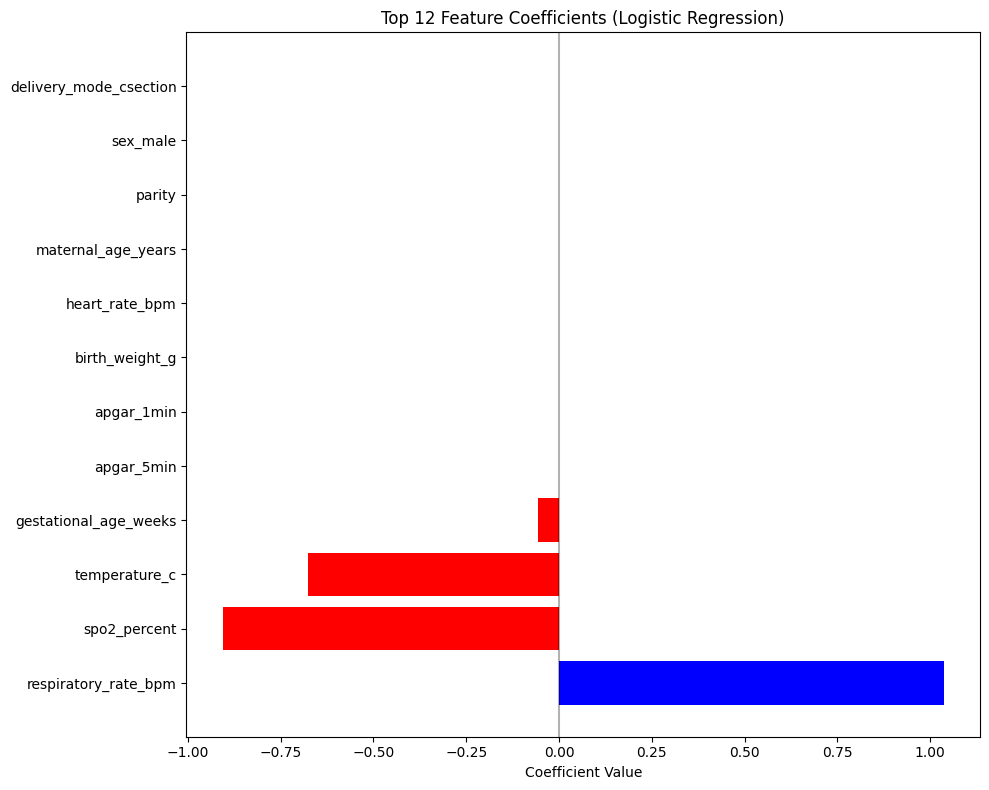


 Feature Statistics:
  respiratory_rate_bpm: 1.0373 (INCREASES risk)
  spo2_percent: -0.9066 (DECREASES risk)
  temperature_c: -0.6773 (DECREASES risk)
  gestational_age_weeks: -0.0558 (DECREASES risk)
  apgar_5min: 0.0000 (DECREASES risk)
  apgar_1min: 0.0000 (DECREASES risk)
  birth_weight_g: 0.0000 (DECREASES risk)
  heart_rate_bpm: 0.0000 (DECREASES risk)
  maternal_age_years: 0.0000 (DECREASES risk)
  parity: 0.0000 (DECREASES risk)


In [43]:
# Get coefficients
coefficients = best_lr.coef_[0]

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

print(f"\n Total features: {len(feature_importance)}")
print("\nTop 12 Most Important Features (by coefficient magnitude):")
print(feature_importance.head(12).to_string(index=False))

# Plot (minimum of 15 and actual number of features)
n_features_to_plot = min(15, len(feature_importance))

plt.figure(figsize=(10, 8))
colors = ['red' if c < 0 else 'blue' for c in feature_importance.head(n_features_to_plot)['coefficient']]

# Create y-positions
y_pos = range(n_features_to_plot)

# Plot
plt.barh(y_pos, feature_importance.head(n_features_to_plot)['coefficient'], color=colors)
plt.yticks(y_pos, feature_importance.head(n_features_to_plot)['feature'])
plt.xlabel('Coefficient Value')
plt.title(f'Top {n_features_to_plot} Feature Coefficients (Logistic Regression)')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.savefig('../../reports/figures/model_4_feature_coefficients.png', dpi=150)
plt.show()

# Show feature statistics
print("\n Feature Statistics:")
for i, row in feature_importance.head(10).iterrows():
    direction = "INCREASES risk" if row['coefficient'] > 0 else "DECREASES risk"
    print(f"  {row['feature']}: {row['coefficient']:.4f} ({direction})")

## 11. Test Set Evaluation


 TEST SET EVALUATION

 Low Burden Scenario:
   Accuracy: 0.9683 (96.83%)
   AUC: 0.9949

 High Burden Scenario:
   Accuracy: 0.9222 (92.22%)
   AUC: 0.9836

 Overall Test Performance:
   Accuracy: 0.9453 (94.53%)
   AUC: 0.9890

 Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      0.94      0.97     19525
   High Risk       0.30      0.96      0.46       475

    accuracy                           0.95     20000
   macro avg       0.65      0.95      0.71     20000
weighted avg       0.98      0.95      0.96     20000



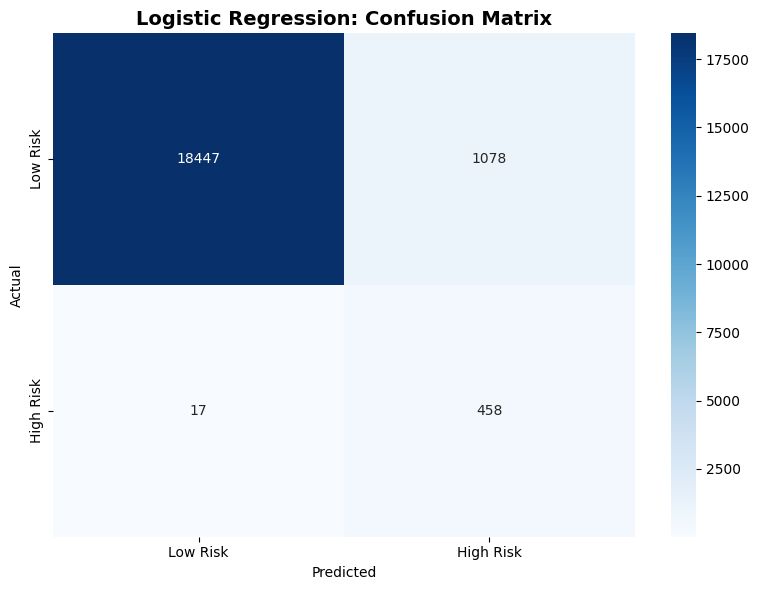

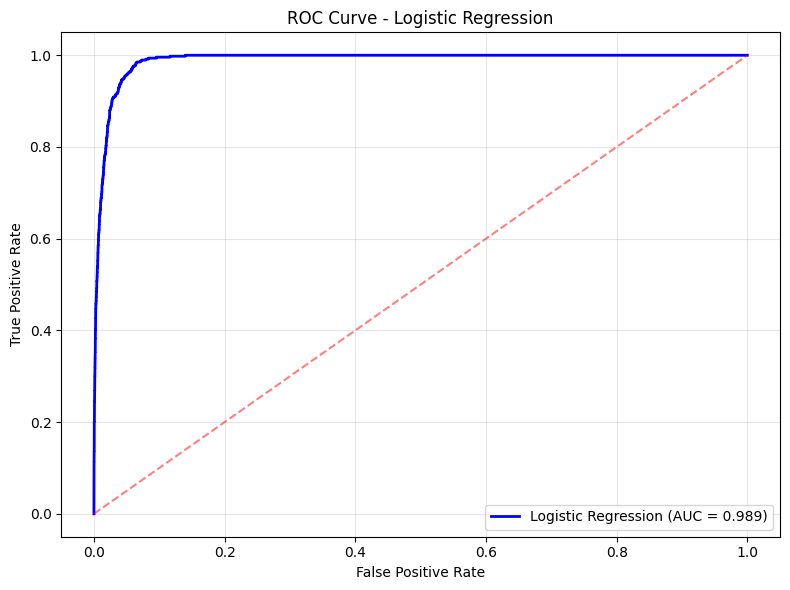

In [44]:
print("\n" + "="*60)
print(" TEST SET EVALUATION")
print("="*60)

# Test on low burden
y_test_low_pred = best_lr.predict(X_test_low_scaled)
y_test_low_proba = best_lr.predict_proba(X_test_low_scaled)[:, 1]

low_accuracy = accuracy_score(y_test_low, y_test_low_pred)
low_auc = roc_auc_score(y_test_low, y_test_low_proba)

print(f"\n Low Burden Scenario:")
print(f"   Accuracy: {low_accuracy:.4f} ({low_accuracy*100:.2f}%)")
print(f"   AUC: {low_auc:.4f}")

# Test on high burden
y_test_high_pred = best_lr.predict(X_test_high_scaled)
y_test_high_proba = best_lr.predict_proba(X_test_high_scaled)[:, 1]

high_accuracy = accuracy_score(y_test_high, y_test_high_pred)
high_auc = roc_auc_score(y_test_high, y_test_high_proba)

print(f"\n High Burden Scenario:")
print(f"   Accuracy: {high_accuracy:.4f} ({high_accuracy*100:.2f}%)")
print(f"   AUC: {high_auc:.4f}")

# Overall test performance
X_test = np.vstack([X_test_low_scaled, X_test_high_scaled])
y_test = np.concatenate([y_test_low, y_test_high])
y_test_pred = best_lr.predict(X_test)
y_test_proba = best_lr.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_proba)

print(f"\n Overall Test Performance:")
print(f"   Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   AUC: {test_auc:.4f}")

# Classification report
print("\n Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Low Risk', 'High Risk']))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])
plt.title('Logistic Regression: Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../../reports/figures/model_4_confusion_matrix.png', dpi=150)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'Logistic Regression (AUC = {test_auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../reports/figures/mode_l4_roc_curve.png', dpi=150)
plt.show()

 ## 12. Save Model

In [45]:
# Save model
joblib.dump(best_lr, "../models/model_4_clinical_logistic.pkl")
print(" Model saved: models/model_4_clinical_logistic.pkl")

# Save feature names
np.save("../models/model_4_feature_names.npy", feature_columns)
print(" Feature names saved")

# Save test predictions for fusion
np.save("../../sound_data/model_data/model_4_test_proba.npy", y_test_proba)
np.save("../../sound_data/model_data/model_4_test_labels.npy", y_test)
print(" Test predictions saved for fusion")

# Save metadata
model_4_metadata = {
    'best_params': grid_search.best_params_,
    'test_accuracy': float(test_accuracy),
    'test_auc': float(test_auc),
    'low_burden_auc': float(low_auc),
    'high_burden_auc': float(high_auc),
    'feature_names': feature_columns,
    'coefficients': coefficients.tolist()
}

with open('../models/model_4_metadata.json', 'w') as f:
    json.dump(model_4_metadata, f, indent=2)

print("\n" + "="*60)
print(" MODEL 4 COMPLETE")
print("="*60)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test AUC: {test_auc:.4f}")
print(f"Low Burden AUC: {low_auc:.4f}")
print(f"High Burden AUC: {high_auc:.4f}")

 Model saved: models/model_4_clinical_logistic.pkl
 Feature names saved
 Test predictions saved for fusion

 MODEL 4 COMPLETE
Test Accuracy: 94.53%
Test AUC: 0.9890
Low Burden AUC: 0.9949
High Burden AUC: 0.9836
